# Thesis Figures

Standalone notebook for generating thesis-ready figures that don't belong to a specific analysis notebook.

Contents:
1. Preprocessing pipeline figure (raw -> segmented -> eroded -> final ROI)
2. Erosion kernel size justification
3. Dataset demographics summary table

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom

print("Imports OK")

Imports OK


## 1. Preprocessing pipeline figure

Shows the 4 stages of the pipeline for one example study (01_01):
- (A) Raw DICOM image
- (B) Image with segmentation mask overlay
- (C) Image with eroded mask overlay (K=3)
- (D) Final segmented ROI

In [2]:
study_id = "01_01"

dicom_dir = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", study_id, "20181008")
preproc_dir = os.path.join("..", "data", "PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED")
eroded_dir = os.path.join("..", "data", "PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED_ERODED_K3_I1")

# Panel A: raw DICOM
dicom_files = [f for f in os.listdir(dicom_dir) if not f.startswith(".")]
ds = pydicom.dcmread(os.path.join(dicom_dir, dicom_files[0]))
raw_image = ds.pixel_array

# Panel B: grayscale image + segmentation mask
image_gray = cv2.imread(os.path.join(preproc_dir, f"{study_id}_image.png"), cv2.IMREAD_GRAYSCALE)
mask_seg = cv2.imread(os.path.join(preproc_dir, f"{study_id}_mask.png"), cv2.IMREAD_GRAYSCALE)

# Panel C: eroded mask
mask_eroded = cv2.imread(
    os.path.join(eroded_dir, "masks", f"{study_id}_mask_eroded_k3_i1.png"), cv2.IMREAD_GRAYSCALE
)

# Panel D: final segmented ROI
segmented = cv2.imread(
    os.path.join(eroded_dir, "segmented", f"{study_id}_segmented_k3_i1.png"), cv2.IMREAD_GRAYSCALE
)

print(f"Raw DICOM: {raw_image.shape}")
print(f"Grayscale image: {image_gray.shape}")
print(f"Segmentation mask: {mask_seg.shape}, nonzero pixels: {np.count_nonzero(mask_seg)}")
print(f"Eroded mask: {mask_eroded.shape}, nonzero pixels: {np.count_nonzero(mask_eroded)}")

Raw DICOM: (768, 1024, 3)
Grayscale image: (768, 1024)
Segmentation mask: (768, 1024), nonzero pixels: 19301
Eroded mask: (768, 1024), nonzero pixels: 18299


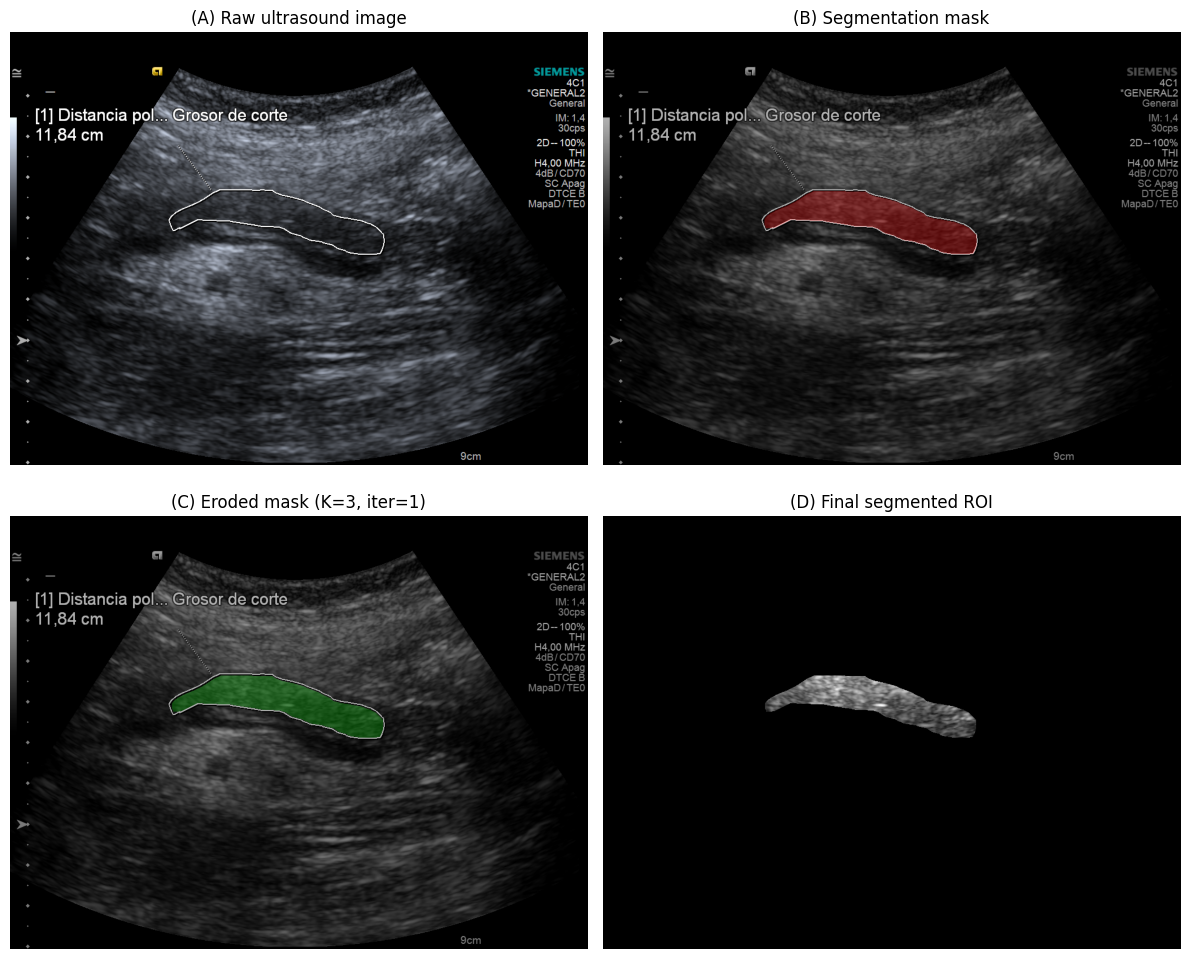

Saved to reports/thesis_preprocessing_pipeline.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (A) Raw DICOM
axes[0, 0].imshow(raw_image)
axes[0, 0].set_title("(A) Raw ultrasound image", fontsize=12)
axes[0, 0].axis("off")

# (B) Segmentation mask overlay
overlay_seg = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_color = np.zeros_like(overlay_seg)
mask_color[mask_seg > 0] = [255, 0, 0]
overlay_seg = cv2.addWeighted(overlay_seg, 0.7, mask_color, 0.3, 0)
axes[0, 1].imshow(overlay_seg)
axes[0, 1].set_title("(B) Segmentation mask", fontsize=12)
axes[0, 1].axis("off")

# (C) Eroded mask overlay
overlay_eroded = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_color_e = np.zeros_like(overlay_eroded)
mask_color_e[mask_eroded > 0] = [0, 200, 0]
overlay_eroded = cv2.addWeighted(overlay_eroded, 0.7, mask_color_e, 0.3, 0)
axes[1, 0].imshow(overlay_eroded)
axes[1, 0].set_title("(C) Eroded mask (K=3, iter=1)", fontsize=12)
axes[1, 0].axis("off")

# (D) Final segmented ROI
axes[1, 1].imshow(segmented, cmap="gray")
axes[1, 1].set_title("(D) Final segmented ROI", fontsize=12)
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join("reports", "thesis_preprocessing_pipeline.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/thesis_preprocessing_pipeline.png")

## 2. Erosion kernel size justification

Shows the distribution of mask pixel loss across kernel sizes (1, 2, 3, 5). K=3 was chosen as a balance between removing boundary artifacts and preserving ROI area.

Erosion report: 528 rows, 132 studies
Kernels: [np.int64(1), np.int64(2), np.int64(3), np.int64(5)]


/var/folders/lf/03m7vbm52qg6m15sdv2knnm80000gp/T/ipykernel_96539/4014105089.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_kernel, labels=[str(k) for k in kernel_values], patch_artist=True)


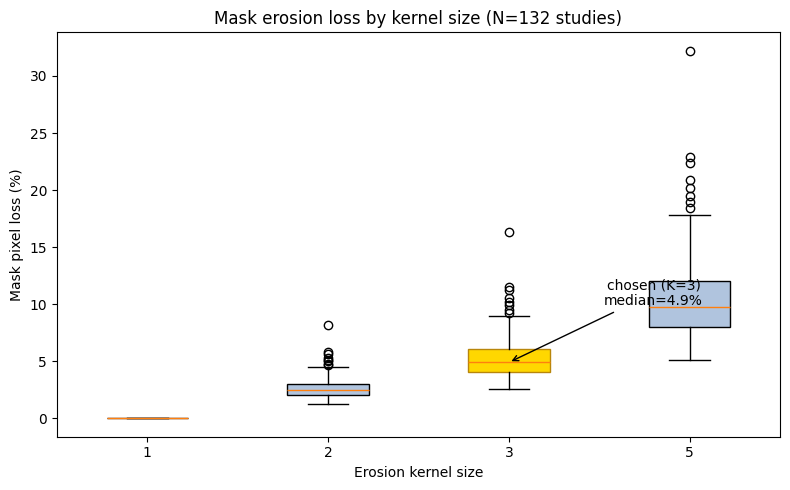

Saved to reports/thesis_erosion_loss_by_kernel.png


In [4]:
erosion_df = pd.read_csv(os.path.join("reports", "09_mask_erosion_loss_report.csv"))
print(f"Erosion report: {len(erosion_df)} rows, {erosion_df['study_id'].nunique()} studies")

kernel_values = sorted(erosion_df["kernel"].unique())
print(f"Kernels: {kernel_values}")

data_by_kernel = []
for k in kernel_values:
    data_by_kernel.append(erosion_df[erosion_df["kernel"] == k]["lost_pct"].values)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_by_kernel, labels=[str(k) for k in kernel_values], patch_artist=True)

chosen_idx = kernel_values.index(3)
for i, box in enumerate(bp["boxes"]):
    if i == chosen_idx:
        box.set_facecolor("#FFD700")
        box.set_edgecolor("#B8860B")
    else:
        box.set_facecolor("#B0C4DE")

ax.set_xlabel("Erosion kernel size")
ax.set_ylabel("Mask pixel loss (%)")
ax.set_title(f"Mask erosion loss by kernel size (N={erosion_df['study_id'].nunique()} studies)")

median_k3 = erosion_df[erosion_df["kernel"] == 3]["lost_pct"].median()
ax.annotate(f"chosen (K=3)\nmedian={median_k3:.1f}%",
            xy=(chosen_idx + 1, median_k3),
            xytext=(chosen_idx + 1.8, median_k3 + 5),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, ha="center")

plt.tight_layout()
plt.savefig(os.path.join("reports", "thesis_erosion_loss_by_kernel.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/thesis_erosion_loss_by_kernel.png")

## 3. Dataset demographics

Summary table comparing the full dataset (137 studies) and independent dataset (55 studies).

In [5]:
full_ds = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
indep_ds = pd.read_csv(os.path.join("reports", "18_independent_dataset.csv"))

def summarize_dataset(df, label):
    studies_per_patient = df.groupby("patient_id").size()
    motivo_counts = df["motivo"].value_counts().sort_index()
    motivo_str = ", ".join(f"m{k}:{v}" for k, v in motivo_counts.items())
    return {
        "dataset": label,
        "studies": len(df),
        "patients": df["patient_id"].nunique(),
        "studies_per_patient": f"{studies_per_patient.mean():.1f} ({studies_per_patient.min()}-{studies_per_patient.max()})",
        "no_rejection": int((df["rejection"] == 0).sum()),
        "rejection": int((df["rejection"] == 1).sum()),
        "rejection_pct": f"{100 * df['rejection'].mean():.1f}%",
        "motivo_distribution": motivo_str,
    }

demographics = pd.DataFrame([
    summarize_dataset(full_ds, "Full (137 studies)"),
    summarize_dataset(indep_ds, "Independent (55 studies)"),
])

print(demographics.to_string(index=False))

                 dataset  studies  patients studies_per_patient  no_rejection  rejection rejection_pct               motivo_distribution
      Full (137 studies)      137        55           2.5 (1-6)            98         39         28.5% m1:30, m2:37, m3:27, m4:23, m5:20
Independent (55 studies)       55        55           1.0 (1-1)            34         21         38.2%         m1:23, m2:14, m4:17, m5:1


In [6]:
output_path = os.path.join("reports", "thesis_dataset_demographics.csv")
demographics.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to reports/thesis_dataset_demographics.csv
